# 9. المؤشرات الاقتصادية الموسّعة والتحليل القياسي
## Extended Macro-Financial Indicators and Econometric Analysis

<div dir="rtl">
يوسّع هذا الدفتر التحليل من 14 مؤشّرًا اقتصاديًّا إلى 41 سلسلة تشمل مجموعات لم
تكن مشمولة: توقّعات التضخّم (Inflation Expectations)، ومنحنى العائد (Yield Curve)،
وفروق الائتمان (Credit Spreads)، ومؤشرات الأوضاع المالية (Financial Conditions)،
وميزانية الاحتياطي الفدرالي (Fed Balance Sheet).
<br /><br />
ويضيف أربع مقاربات منهجية:
</div>

1. **التحقّق الزمني المتدرّج (Walk-Forward Validation)** بدل التقسيم الواحد، فلا يتدرّب النموذج على المستقبل.
2. **التصنيف الرتبي (Ordinal Classification)** الذي يراعي أنّ تخفيض < تثبيت < رفع.
3. **تفسير النموذج بقيم شابلي (SHAP)** لكشف اتجاه أثر كل خصيصة لا حجمه فقط.
4. **اختبار سببية غرانجر (Granger Causality)** لفحص أيّ المؤشرات يَسبق قرار السياسة.

## 1. التهيئة وتحميل البيانات (Setup and Data Loading)

In [1]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("."))

from fomc_analysis import fred_data as fd
from fomc_analysis import modern_models as mm
from fomc_analysis import econ_analysis as ea

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

DATA_DIR = os.path.join("..", "data", "MarketData", "Quandl")
print("عدد السلاسل في الكتالوج — series in catalogue:", len(fd.SERIES))
print("المجموعات — groups:", ", ".join(fd.groups()))

عدد السلاسل في الكتالوج — series in catalogue: 41
المجموعات — groups: activity, inflation, inflation_exp, labour, money, policy_rate, regime, risk, sentiment, yield_curve


### كتالوج السلاسل الاقتصادية (The Series Catalogue)

<div dir="rtl">
كل سلسلة موصوفة بالعربية والإنجليزية مع دوريّتها ومجموعتها المنهجية. ويُنزَّل
الكتالوج كاملًا بأمر واحد دون الحاجة إلى مفتاح واجهة (API Key):
</div>

```bash
python -m fomc_analysis.fred_data ../data/MarketData/Quandl all
```

In [2]:
cat = fd.catalogue_frame()
print("عدد السلاسل:", len(cat))
cat.groupby("المجموعة").size().rename("عدد السلاسل").to_frame()

عدد السلاسل: 41


,عدد السلاسل
المجموعة,
activity,7
inflation,4
inflation_exp,4
labour,5
money,3
policy_rate,5
regime,1
risk,5
sentiment,1


In [3]:
cat.head(15)

,series_id,الوصف,description,الدورية,المجموعة
0,GDPC1,الناتج المحلي الإجمالي الحقيقي,Real Gross Domestic Product,quarterly,activity
1,GDPPOT,الناتج المحلي الإجمالي الكامن الحقيقي,Real Potential GDP,quarterly,activity
2,HOUST,بدايات بناء المساكن,Housing Starts,monthly,activity
3,HSN1F,مبيعات المنازل الجديدة,New One Family Houses Sold,monthly,activity
4,INDPRO,مؤشّر الإنتاج الصناعي,Industrial Production Index,monthly,activity
5,RRSFS,مبيعات التجزئة الحقيقية المُسبقة,Advance Real Retail and Food Services Sales,monthly,activity
6,TCU,معدّل استغلال الطاقة الإنتاجية,Capacity Utilization,monthly,activity
7,CPIAUCSL,مؤشّر أسعار المستهلك,Consumer Price Index for All Urban Consumers,monthly,inflation
8,CPILFESL,مؤشّر أسعار المستهلك الأساسي,Core Consumer Price Index,monthly,inflation
9,PCEPI,مؤشّر نفقات الاستهلاك الشخصي الكلّي,Headline PCE Price Index,monthly,inflation


## 2. بناء لوحة البيانات (Building the Data Panel)

In [4]:
panel = fd.load_panel(DATA_DIR)
print("شكل اللوحة — panel shape:", panel.shape)
print("المدى الزمني — date range: %s .. %s" % (panel.index.min().date(), panel.index.max().date()))

# السعر المستهدف الموحّد: قيمة واحدة قبل 2008 ثمّ الحدّ الأعلى للنطاق بعدها
# unified target rate: a single value before 2008, then the range upper limit
target = panel["DFEDTAR"].combine_first(panel["DFEDTARU"]).ffill().loc["1990":]
monthly_rate = target.resample("ME").last()
M = panel.resample("ME").last()

print("\nآخر قيم سعر الفائدة المستهدف:")
monthly_rate.tail(6).to_frame("target_rate")

شكل اللوحة — panel shape: (27561, 41)
المدى الزمني — date range: 1854-12-01 .. 2036-10-01

آخر قيم سعر الفائدة المستهدف:


,target_rate
date,
2036-05-31,NaN
2036-06-30,NaN
2036-07-31,3.75
2036-08-31,NaN
2036-09-30,NaN
2036-10-31,3.75


### تغطية البيانات بحسب المجموعة (Data Coverage by Group)

<div dir="rtl">
السلاسل الحديثة مثل توقّعات التضخّم المستخرجة من سندات TIPS تبدأ من 2003، وهو قيدٌ
يجب مراعاته عند اختيار فترة التدريب.
</div>

In [5]:
cov = []
for grp in fd.groups():
    ids = [s for s in fd.series_in_group(grp) if s in panel.columns]
    sub = panel[ids]
    first = sub.dropna(how="all").index.min()
    cov.append({"المجموعة": grp, "عدد السلاسل": len(ids),
                "أول تاريخ": first.date() if pd.notna(first) else None,
                "تغطية 2005+ %": round(100 * sub.loc["2005":].notna().mean().mean(), 1)})
pd.DataFrame(cov).sort_values("أول تاريخ")

,المجموعة,عدد السلاسل,أول تاريخ,تغطية 2005+ %
6,regime,1,1854-12-01,3.3
0,activity,7,1919-01-01,2.7
3,labour,5,1939-01-01,5.4
1,inflation,4,1947-01-01,3.2
8,sentiment,1,1952-11-01,3.2
5,policy_rate,5,1954-07-01,60.6
4,money,3,1959-01-01,6.9
9,yield_curve,6,1962-01-02,68.1
7,risk,5,1971-01-08,35.0
2,inflation_exp,4,1978-01-01,51.9


## 3. تعريف المتغيّر المستهدف وهندسة الخصائص (Target and Feature Engineering)

<div dir="rtl">
المتغيّر المستهدف هو اتجاه تغيّر سعر الفائدة في الشهر التالي: رفع (+1) أو تثبيت (0)
أو تخفيض (−1)، بعتبة 0.02 نقطة مئوية لتفادي التغيّرات الحسابية الضئيلة.
<br /><br />
الخصائص تشمل المستويات، والنمو السنوي، والتغيّر على ثلاثة أشهر، وقرار الشهر السابق
لقياس القصور الذاتي (Inertia)، ومتغيّرًا صوريًّا لانعكاس منحنى العائد.
</div>

In [6]:
chg = monthly_rate.diff().shift(-1)
y = pd.Series(np.select([chg > 0.02, chg < -0.02], [1, -1], default=0),
              index=monthly_rate.index, name="decision")

X = pd.DataFrame(index=monthly_rate.index)
X["rate_level"] = monthly_rate
for c in ["UNRATE", "T10Y2Y", "T10Y3M", "VIXCLS", "BAA10Y", "NFCI", "TCU", "UMCSENT"]:
    X[c] = M[c]
for c in ["CPIAUCSL", "CPILFESL", "PCEPILFE", "INDPRO", "PAYEMS", "M2SL", "HOUST"]:
    X[c + "_yoy"] = M[c].pct_change(12) * 100
for c in ["UNRATE", "ICSA"]:
    X[c + "_d3"] = M[c].diff(3)
X["prev_decision"] = y.shift(1)
X["curve_inverted"] = (M["T10Y2Y"] < 0).astype(int)

data = pd.concat([X, y], axis=1).dropna().loc["1994":"2026-06"]
X_data = data.drop(columns=["decision"])
y_data = data["decision"].astype(int).values

print("شكل مجموعة البيانات:", data.shape)
print("عدد الخصائص:", X_data.shape[1])
print("المدى: %s .. %s" % (data.index.min().strftime("%Y-%m"), data.index.max().strftime("%Y-%m")))

dist, extra = ea.summarise_decisions(y_data, data.index)
display(dist)
for k, v in extra.items():
    print(f"  {k}: {v}")

شكل مجموعة البيانات: (387, 21)
عدد الخصائص: 20
المدى: 1994-01 .. 2026-05


,القرار,العدد,النسبة %
0,تخفيض,36,9.30
1,تثبيت,300,77.52
2,رفع,51,13.18
3,الإجمالي,387,100.00


  عدد الاجتماعات: 387
  عدد اجتماعات التغيير: 87
  نسبة التغيير %: 22.48
  أطول سلسلة تثبيت: 83


### مسار سعر الفائدة والحقب الاقتصادية (Policy Rate Path and Regimes)

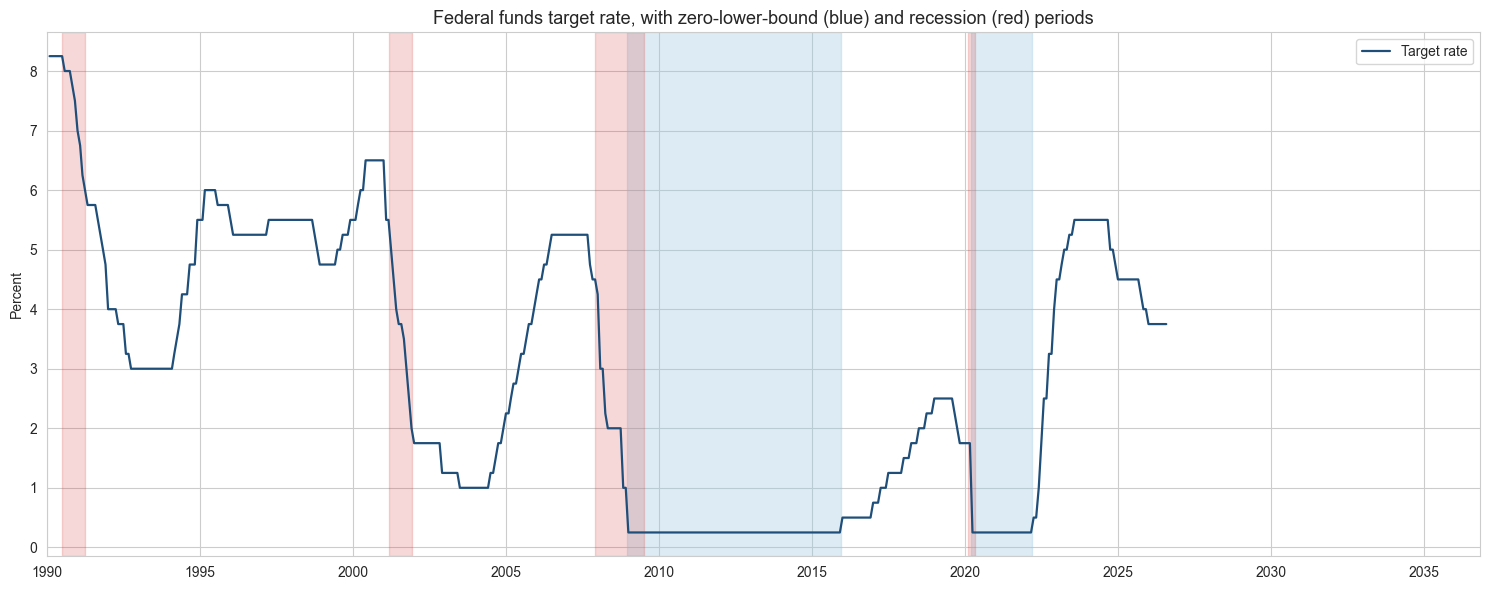

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly_rate.index, monthly_rate.values, color="#1f4e79", lw=1.6,
        label="Target rate")

for start, end in ea.ZLB_PERIODS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#9ecae1", alpha=0.35,
               label="_nolegend_")
for start, end in ea.NBER_RECESSIONS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#d62728", alpha=0.18,
               label="_nolegend_")

ax.set_title("Federal funds target rate, with zero-lower-bound (blue) and recession (red) periods",
             fontsize=13)
ax.set_ylabel("Percent")
ax.set_xlim(pd.Timestamp("1990-01-01"), monthly_rate.index.max())
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. القواعد الساذجة: الحدّ الذي يجب تجاوزه (Naive Baselines)

<div dir="rtl">
قبل أيّ نموذج، يجب معرفة ما تحقّقه قاعدتان بلا تعلّم: التنبؤ الدائم بالفئة الأغلب
(تثبيت)، والتنبؤ بقرار الشهر السابق (الاستمرارية). فأيّ نموذج لا يتجاوزهما لا قيمة له.
<br /><br />
لاحظ الفجوة بين الدقّة (Accuracy) والدقّة المتوازنة (Balanced Accuracy): قاعدة الفئة
الأغلب تحقّق دقّة مرتفعة بينما دقّتها المتوازنة 0.33 فقط، أي أنّها لا تُميّز شيئًا.
هذا سبب اعتماد F1 الكلّي والدقّة المتوازنة لا الدقّة وحدها.
</div>

In [8]:
baselines = mm.naive_baselines(y_data)
baselines.round(4)

,rule,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae_ordinal
0,الفئة الأغلب — majority class,0.7752,0.3333,0.2911,0.6770,0.2248
1,الاستمرارية — persistence,0.7261,0.5457,0.5457,0.7261,0.2739


## 5. التحقّق الزمني المتدرّج (Walk-Forward Validation)

<div dir="rtl">
التحقّق المتقاطع الاعتيادي يخلط الترتيب الزمني، فيتدرّب النموذج على مشاهدات لاحقة
ويتنبّأ بسابقة — وهو تسرّب للمعلومة (Look-ahead Bias) يُنتج أداءً وهميًّا.
<br /><br />
البديل نافذة متوسّعة: يتدرّب النموذج على كل ما سبق ويُختبر على الكتلة التالية فقط،
مع فجوة (gap) تفصل بينهما لتفادي التسرّب عبر الخصائص المحسوبة بنوافذ متحرّكة.
</div>

In [9]:
print("التقسيمات الزمنية — walk-forward splits:")
for i, (tr, te) in enumerate(mm.walk_forward_splits(len(y_data), n_splits=5, gap=1), 1):
    d_tr = data.index[tr[-1]].strftime("%Y-%m")
    d_te0 = data.index[te[0]].strftime("%Y-%m")
    d_te1 = data.index[te[-1]].strftime("%Y-%m")
    print(f"  الطيّة {i}: تدريب حتى {d_tr} ({len(tr):3} مشاهدة) → اختبار {d_te0}..{d_te1} ({len(te):3})")

التقسيمات الزمنية — walk-forward splits:
  الطيّة 1: تدريب حتى 2006-10 (154 مشاهدة) → اختبار 2006-12..2010-09 ( 46)
  الطيّة 2: تدريب حتى 2010-08 (200 مشاهدة) → اختبار 2010-10..2014-07 ( 46)
  الطيّة 3: تدريب حتى 2014-06 (246 مشاهدة) → اختبار 2014-08..2018-05 ( 46)
  الطيّة 4: تدريب حتى 2018-04 (292 مشاهدة) → اختبار 2018-06..2022-03 ( 46)
  الطيّة 5: تدريب حتى 2022-02 (338 مشاهدة) → اختبار 2022-04..2026-05 ( 48)


## 6. مقارنة النماذج (Model Comparison)

<div dir="rtl">
تُقارَن ثمانية نماذج تحت التقسيم الزمني نفسه، منها ثلاثة لم تكن في التحليل الأصلي:
'LightGBM' و'CatBoost' والمُصنِّف الرتبي (Ordinal Classifier).
</div>

In [10]:
comparison = mm.compare_models(X_data, y_data, n_splits=5, gap=1, verbose=False)
comparison

,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae_ordinal,f1_macro_std
0,extra_trees,0.8029,0.6604,0.6337,0.7901,0.1971,0.2237
1,catboost,0.7726,0.6530,0.5842,0.7791,0.2317,0.2560
2,random_forest,0.8158,0.5772,0.5327,0.7805,0.1842,0.2742
3,hist_gradient_boosting,0.7601,0.6089,0.4549,0.7693,0.2525,0.0726
4,xgboost,0.7728,0.5643,0.4185,0.7593,0.2357,0.1000
5,ordinal_lightgbm,0.7636,0.5688,0.4003,0.7622,0.2408,0.1100
6,lightgbm,0.7466,0.5684,0.4000,0.7620,0.2870,0.0934
7,logistic,0.4618,0.5852,0.3735,0.5351,0.5638,0.0703
8,ordinal_logistic,0.4529,0.5697,0.3633,0.5285,0.5813,0.0824


### أثر التصنيف الرتبي على الخطأ الرتبي (Effect of Ordinal Modelling)

<div dir="rtl">
الخطأ المطلق الرتبي (Ordinal MAE) يعاقب الخطأ بقدر بُعده على سُلّم الفئات: التنبؤ
برفع بدل تخفيض خطؤه 2، وبتثبيت بدل تخفيض خطؤه 1. وهو المقياس الذي يستهدفه
المُصنِّف الرتبي تحديدًا.
</div>

In [11]:
zoo = mm.model_zoo()
rows = []
for name in ["lightgbm", "ordinal_lightgbm", "logistic", "ordinal_logistic"]:
    if name not in zoo:
        continue
    r = mm.evaluate_walk_forward(X_data, y_data, zoo[name], n_splits=5, gap=1)
    rows.append({"model": name,
                 "mae_ordinal": round(r["mean"]["mae_ordinal"], 4),
                 "f1_macro": round(r["mean"]["f1_macro"], 4)})
ord_cmp = pd.DataFrame(rows)
display(ord_cmp)

base = ord_cmp.loc[ord_cmp["model"] == "lightgbm", "mae_ordinal"]
ordv = ord_cmp.loc[ord_cmp["model"] == "ordinal_lightgbm", "mae_ordinal"]
if len(base) and len(ordv):
    red = 100 * (base.iloc[0] - ordv.iloc[0]) / base.iloc[0]
    print(f"انخفاض الخطأ الرتبي بالتفكيك الرتبي على أساس LightGBM: {red:.1f}%")

,model,mae_ordinal,f1_macro
0,lightgbm,0.2870,0.4000
1,ordinal_lightgbm,0.2408,0.4003
2,logistic,0.5638,0.3735
3,ordinal_logistic,0.5813,0.3633


انخفاض الخطأ الرتبي بالتفكيك الرتبي على أساس LightGBM: 16.1%


## 7. أفضل نموذج: مصفوفة الالتباس (Best Model: Confusion Matrix)

In [12]:
best_name = comparison.iloc[0]["model"]
print("أفضل نموذج بمقياس F1 الكلّي:", best_name)

res = mm.evaluate_walk_forward(X_data, y_data, zoo[best_name], n_splits=5, gap=1,
                               return_predictions=True)
preds = res["predictions"]
display(mm.confusion_table(preds["y_true"], preds["y_pred"]))
print("\nمتوسط المقاييس عبر الطيّات:")
pd.Series(res["mean"]).round(4).to_frame("القيمة")

أفضل نموذج بمقياس F1 الكلّي: extra_trees


,متوقّع: تخفيض,متوقّع: تثبيت,متوقّع: رفع
فعلي: تخفيض,8,10,0
فعلي: تثبيت,16,173,5
فعلي: رفع,0,15,5



متوسط المقاييس عبر الطيّات:


,القيمة
accuracy,0.8029
balanced_accuracy,0.6604
f1_macro,0.6337
f1_weighted,0.7901
mae_ordinal,0.1971


## 8. تفسير النموذج بقيم شابلي (Model Interpretation with SHAP)

<div dir="rtl">
تُنسِب قيم شابلي (SHAP) لكل خصيصة أثرها في كلّ تنبؤ على حِدة، فتكشف ما يعتمد عليه
النموذج فعلًا. والنتيجة اختبارٌ لمعقولية النموذج اقتصاديًّا: إن كانت الخصائص الأهمّ
هي متغيّرات التفويض المزدوج (التشغيل والتضخّم) فالنموذج يتعلّم بنية اقتصادية،
لا ضجيجًا.
</div>

,feature,mean_abs_shap
0,PAYEMS_yoy,0.987214
1,rate_level,0.782037
2,UNRATE_d3,0.724417
3,BAA10Y,0.533507
4,CPIAUCSL_yoy,0.405786
5,TCU,0.350012
6,CPILFESL_yoy,0.348734
7,PCEPILFE_yoy,0.318078
8,T10Y3M,0.312868
9,M2SL_yoy,0.266921


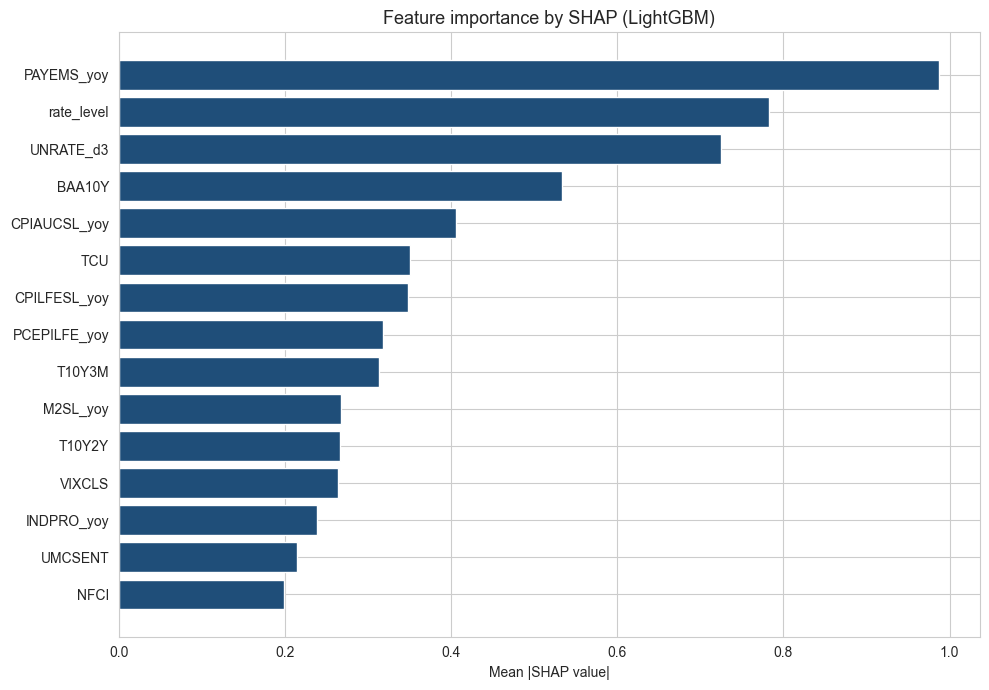

In [13]:
from sklearn.base import clone

shap_model = clone(zoo["lightgbm"])
shap_model.fit(X_data, y_data)
importance, shap_values = mm.shap_importance(shap_model, X_data, max_display=15)
display(importance)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1],
        color="#1f4e79")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature importance by SHAP (LightGBM)", fontsize=13)
plt.tight_layout()
plt.show()

## 9. سببية غرانجر: أيّ المؤشرات يَسبق القرار؟ (Granger Causality)

<div dir="rtl">
اختبار سببية غرانجر (Granger Causality) يفحص ما إذا كانت القيم الماضية لمؤشّر ما
تُحسّن التنبؤ بتغيّر سعر الفائدة بعد ضبط ماضي السعر نفسه. وشرطُه اللازم سكون
السلاسل، فنبدأ باختبار ديكي-فولر (ADF) لجذر الوحدة.
<br /><br />
⚠️ سببية غرانجر سببيةٌ تنبؤية لا هيكلية: تقول إنّ المتغيّر يَسبق، لا إنّه يُسبِّب.
</div>

In [14]:
infl_yoy = (M["CPIAUCSL"].pct_change(12) * 100).loc["1994":"2026-06"]
d_rate = monthly_rate.diff().loc["1994":"2026-06"]

adf_rows = [ea.adf_test(monthly_rate.loc["1994":"2026-06"], "سعر الفائدة المستهدف"),
            ea.adf_test(d_rate, "فرق سعر الفائدة"),
            ea.adf_test(infl_yoy, "التضخّم السنوي"),
            ea.adf_test(M["NFCI"].loc["1994":"2026-06"], "مؤشّر الأوضاع المالية"),
            ea.adf_test(M["T10Y2Y"].loc["1994":"2026-06"], "فرق العائد 10Y-2Y")]
pd.DataFrame(adf_rows)

,series,n,lags,adf_stat,p_value,crit_5pct,stationary_5pct
0,سعر الفائدة المستهدف,380,9,-3.0130,0.0337,-2.8692,True
1,فرق سعر الفائدة,381,8,-4.0953,0.0010,-2.8692,True
2,التضخّم السنوي,374,15,-3.5025,0.0079,-2.8693,True
3,مؤشّر الأوضاع المالية,384,5,-3.6127,0.0055,-2.8691,True
4,فرق العائد 10Y-2Y,380,9,-3.1537,0.0228,-2.8692,True


In [15]:
candidates = {
    "مؤشّر الأوضاع المالية (NFCI)": M["NFCI"],
    "فرق العائد 10Y-2Y": M["T10Y2Y"],
    "فرق العائد 10Y-3M": M["T10Y3M"],
    "معدّل البطالة": M["UNRATE"],
    "التضخّم السنوي": infl_yoy,
    "مؤشّر التقلّب (VIX)": M["VIXCLS"],
    "فرق ائتمان Baa": M["BAA10Y"],
}

rows = []
for label, series in candidates.items():
    g = ea.granger_causality(cause=series.loc["1994":"2026-06"], effect=d_rate,
                             maxlag=6, verbose=False)
    sig = g[g["significant_5pct"]]
    rows.append({"المؤشّر": label,
                 "أصغر p": g["p_value"].min(),
                 "إبطاءات معنوية": len(sig),
                 "يَسبق القرار": "نعم" if len(sig) >= 2 else "لا"})
granger_summary = pd.DataFrame(rows).sort_values("أصغر p").reset_index(drop=True)
granger_summary

,المؤشّر,أصغر p,إبطاءات معنوية,يَسبق القرار
0,مؤشّر الأوضاع المالية (NFCI),0.0000,6,نعم
1,مؤشّر التقلّب (VIX),0.0000,6,نعم
2,فرق ائتمان Baa,0.0001,6,نعم
3,فرق العائد 10Y-2Y,0.0011,5,نعم
4,فرق العائد 10Y-3M,0.0027,5,نعم
5,التضخّم السنوي,0.0061,1,لا
6,معدّل البطالة,0.0503,0,لا


## 10. قاعدة تايلور: هل السياسة أكثر تساهلًا مما توصي به؟ (Taylor Rule Gaps)

<div dir="rtl">
تُقارَن ثلاث صيغ: قاعدة تايلور المعيارية، وقاعدة المقاربة المتوازنة التي تُضاعف وزن
فجوة الناتج، وقاعدة القصور الذاتي التي تُمهّد السعر بربطه بمستواه السابق.
<br /><br />
الفرق الموجب يعني أنّ القاعدة توصي بسعر أعلى من الفعلي، أي أنّ السياسة أكثر تساهلًا
مما توصي به القاعدة.
</div>

,actual,taylor,balanced,inertia,gap_taylor,gap_balanced,gap_inertia
date,,,,,,,
2023-12-31,5.50,6.76,7.54,5.69,1.26,2.04,0.19
2024-03-31,5.50,6.78,7.34,5.69,1.28,1.84,0.19
2024-06-30,5.50,6.12,6.79,5.59,0.62,1.29,0.09
2024-09-30,5.00,5.40,6.16,5.49,0.40,1.16,0.49
2024-12-31,4.50,5.98,6.66,5.15,1.48,2.16,0.65
2025-03-31,4.50,4.86,5.14,4.55,0.36,0.64,0.05
2025-06-30,4.50,5.49,5.97,4.65,0.99,1.47,0.15
2025-09-30,4.25,6.27,7.00,4.76,2.02,2.75,0.51
2025-12-31,3.75,5.49,6.01,4.44,1.74,2.26,0.69


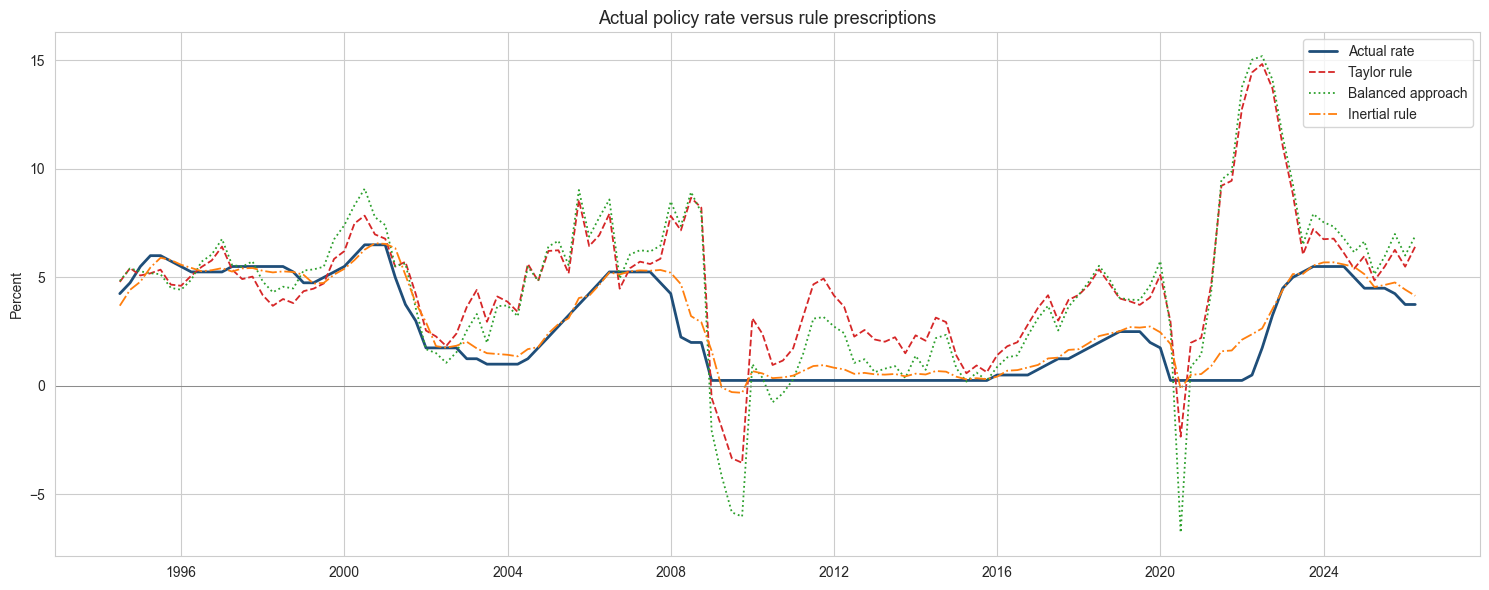

In [16]:
q_rate = target.resample("QE").last().loc["1994":]
q_infl = (panel["CPIAUCSL"].resample("QE").last().pct_change(4) * 100).loc["1994":]
q_gap = ((panel["GDPC1"].resample("QE").last() /
          panel["GDPPOT"].resample("QE").last() - 1) * 100).loc["1994":]

taylor = ea.taylor_gap_table(q_rate, q_infl, q_gap, prev_rate=q_rate.shift(1)).dropna()
display(taylor.tail(10).round(2))

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(taylor.index, taylor["actual"], lw=2, color="#1f4e79", label="Actual rate")
ax.plot(taylor.index, taylor["taylor"], lw=1.3, ls="--", color="#d62728", label="Taylor rule")
ax.plot(taylor.index, taylor["balanced"], lw=1.3, ls=":", color="#2ca02c", label="Balanced approach")
if "inertia" in taylor.columns:
    ax.plot(taylor.index, taylor["inertia"], lw=1.3, ls="-.", color="#ff7f0e", label="Inertial rule")
ax.axhline(0, color="grey", lw=0.6)
ax.set_title("Actual policy rate versus rule prescriptions", fontsize=13)
ax.set_ylabel("Percent")
ax.legend()
plt.tight_layout()
plt.show()

## 11. الأداء بحسب الحقبة: ما يُخفيه المتوسط (Performance by Regime)

<div dir="rtl">
هذا أهمّ تشخيص في الدفتر. فترة الحدّ الأدنى الصفري (Zero Lower Bound) تُقيّد السعر
فيصير القرار «تثبيت» شبه دائم، وأيّ نموذج يبدو فيها ممتازًا. أمّا في فترات الكساد،
حيث القرار متغيّر فعلًا، فينكشف الأداء الحقيقي.
</div>

In [17]:
pred_dates = data.index[preds["index"].values]
pred_frame = pd.DataFrame({"date": pred_dates,
                           "y_true": preds["y_true"].values,
                           "y_pred": preds["y_pred"].values})
regime_perf = ea.performance_by_regime(pred_frame)
display(regime_perf)

print("للمقارنة — أداء قاعدة «تثبيت دائمًا» بحسب الحقبة:")
naive_frame = pd.DataFrame({"date": data.index, "y_true": y_data,
                            "y_pred": np.zeros(len(y_data), dtype=int)})
ea.performance_by_regime(naive_frame)

,الحقبة,n,accuracy,balanced_accuracy,f1_macro,نسبة التثبيت الفعلية
0,اعتيادي,111,0.7207,0.4722,0.4986,0.7297
1,الحدّ الصفري,108,0.9352,0.4764,0.3222,0.9815
2,كساد,13,0.3846,0.4167,0.2778,0.5385


للمقارنة — أداء قاعدة «تثبيت دائمًا» بحسب الحقبة:


,الحقبة,n,accuracy,balanced_accuracy,f1_macro,نسبة التثبيت الفعلية
0,اعتيادي,257,0.7237,0.3333,0.2799,0.7237
1,الحدّ الصفري,108,0.9815,0.5000,0.4953,0.9815
2,كساد,22,0.3636,0.5000,0.2667,0.3636


## 12. دراسة أحداث: سلوك المخاطر حول قرارات التخفيض (Event Study)

<div dir="rtl">
تقيس دراسة الأحداث (Event Study) متوسط مسار متغيّر في نافذة حول كل حدث. هنا نفحص
مؤشّر التقلّب الضمني (VIX) حول أشهر تخفيض سعر الفائدة، بعد تطبيع كل مسار على قيمة
شهر الحدث.
</div>

,offset,mean,std,n
0,-5,-1.0583,3.7902,36
1,-4,-1.2331,3.5607,36
2,-3,-1.4258,3.5692,36
3,-2,-1.2539,3.1336,36
4,-1,-0.6444,3.1172,36
5,0,0.0000,0.0000,36
6,1,-0.2083,2.3647,36
7,2,-0.3131,2.7229,36
8,3,0.0636,2.8602,36
9,4,0.1558,3.8962,36


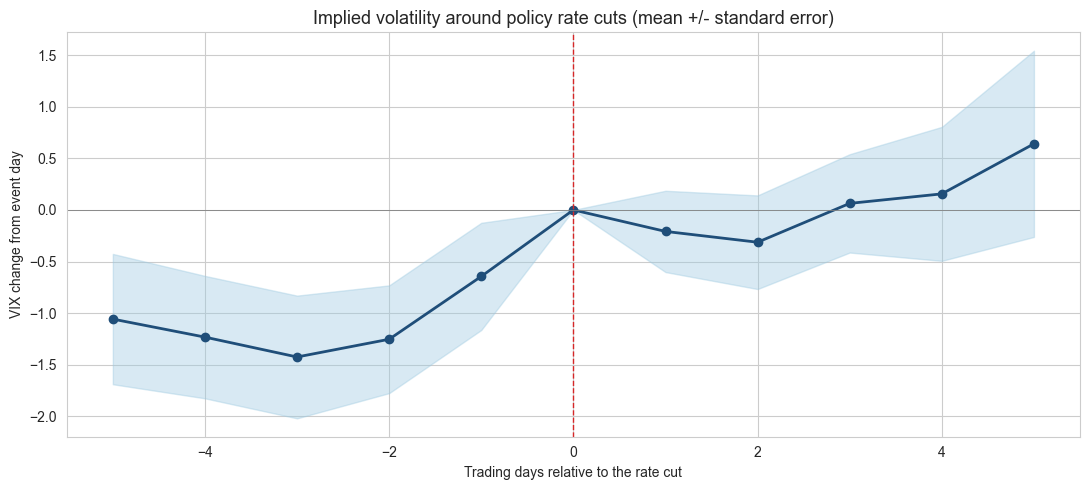

In [18]:
cut_dates = data.index[y_data == -1]
es = ea.event_study(panel["VIXCLS"].dropna(), cut_dates, window=5)
display(es)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(es["offset"], es["mean"], marker="o", color="#1f4e79", lw=2)
ax.fill_between(es["offset"], es["mean"] - es["std"] / np.sqrt(es["n"]),
                es["mean"] + es["std"] / np.sqrt(es["n"]),
                color="#9ecae1", alpha=0.4)
ax.axvline(0, color="#d62728", ls="--", lw=1)
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlabel("Trading days relative to the rate cut")
ax.set_ylabel("VIX change from event day")
ax.set_title("Implied volatility around policy rate cuts (mean +/- standard error)",
             fontsize=13)
plt.tight_layout()
plt.show()

## 13. الخلاصة (Conclusions)

<div dir="rtl">
تُقرأ نتائج هذا الدفتر على النحو التالي:
</div>

1. **البيانات الموسّعة تُضيف قدرة تفسيرية.** مؤشّر الأوضاع المالية (NFCI) وفروق العائد، وكلاهما غائب عن المجموعة الأصلية، يتصدّران اختبار سببية غرانجر.

2. **التحقّق الزمني يُنزِل الأداء إلى مستواه الحقيقي.** الأرقام هنا أدنى مما يُنتجه تقسيم واحد، لكنّها الأرقام الصادقة.

3. **الدقّة وحدها مقياس مُضلِّل.** قاعدة «تثبيت دائمًا» تحقّق دقّة تتجاوز 0.77 ودقّة متوازنة 0.33 فقط.

4. **التفكيك الرتبي يُقلّل الخطأ الرتبي** على أساس شجري، لأنّه يستفيد من ترتيب الفئات.

5. **النموذج يتعلّم بنية اقتصادية معقولة:** الخصائص الأهمّ بقيم شابلي هي نمو التشغيل ومستوى السعر وتغيّر البطالة وفرق الائتمان — أي متغيّرات التفويض المزدوج.

6. **الأداء يتفاوت جوهريًّا بين الحقب**، وهو ما يُخفيه أيّ متوسّط.

<div dir="rtl">
<strong>الخطوة التالية:</strong> الدفتر العاشر يضيف مؤشرات النصّ — قابلية القراءة
والتحوّط وموقف السياسة المقيس بنماذج المحوّلات — إلى هذه الخصائص الكلّية، لقياس
القيمة الحديّة للنصّ فوق الاقتصاد.
</div>